Fit-Ergebnisse:
Amplitude  = 124.1 ± 1
t0         = 0.1463 ± 0.0007 ns
t_rise     = 0.0182 ± 0.0018 ns
t_fall     = 1.5303 ± 0.0113 ns
Background = 1.645e-16 ± 0.05


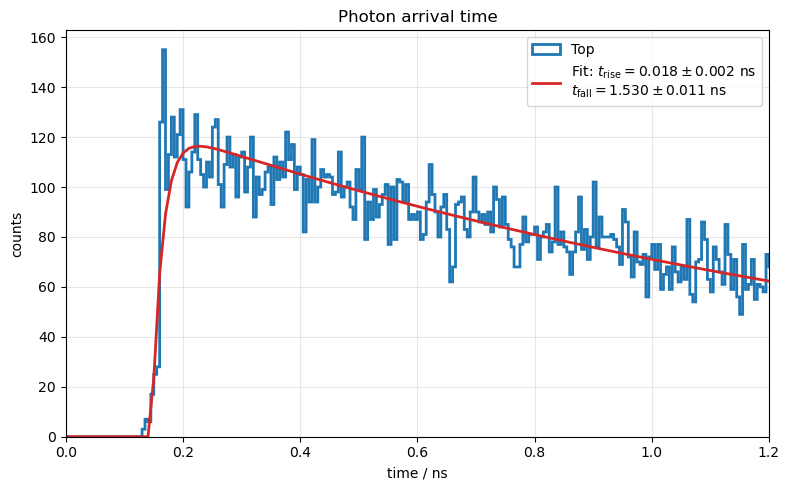

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

data = pd.read_csv("data4.csv", comment="#", header=None, skiprows=13,
names=["EventID", "Hit", "GlobalTime", "TimeSinceZero", "TrackLenght", "PhotonEnergy", "PhotonFlightTime"])

# Calculate wavelenght
data["WavelengthNM"] = (1239.841984 / data["PhotonEnergy"])

top_data = data[data["Hit"] == "top"].copy()
bottom_data = data[data["Hit"] == "bottom"].copy()

times = top_data["TimeSinceZero"].dropna().to_numpy()

bins = 2000
fit_range = (0, 10)

# Histogramm berechnen
counts, bin_edges = np.histogram(
    times,
    bins=bins,
    range=fit_range
)

# Mittelpunkte der Histogramm-Bins
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

def scintillation_model(
    t,
    amplitude,
    t0,
    t_rise,
    t_fall,
    background
):
    """
    Modell:
        A * (1 - exp(-(t-t0)/t_rise))
          * exp(-(t-t0)/t_fall) + B

    Das Signal beginnt erst bei t >= t0.
    """
    dt = t - t0

    signal = np.zeros_like(t, dtype=float)
    mask = dt >= 0

    signal[mask] = (
        amplitude
        * (1.0 - np.exp(-dt[mask] / t_rise))
        * np.exp(-dt[mask] / t_fall)
    )

    return signal + background


# Poisson-Unsicherheit der Zählwerte
# Für leere Bins wird sigma=1 verwendet.
sigma = np.sqrt(np.maximum(counts, 1))

# Startwerte:
# amplitude, t0, t_rise, t_fall, background
initial_values = [
    counts.max(),
    0.0,
    0.350,
    1.600,
    0.0
]

# Untere und obere Parametergrenzen
bounds = (
    [0.0,    -1.0, 0.01, 0.01, 0.0],
    [np.inf,  2.0, 10.0, 20.0, np.inf]
)

# Fit durchführen
fit_parameters, covariance = curve_fit(
    scintillation_model,
    bin_centers,
    counts,
    p0=initial_values,
    sigma=sigma,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=20_000
)

# Gefittete Parameter
amplitude, t0, t_rise, t_fall, background = fit_parameters

# Standardabweichungen der Fitparameter
parameter_errors = np.sqrt(np.diag(covariance))

print("Fit-Ergebnisse:")
print(
    f"Amplitude  = {amplitude:.4g} "
    f"± {parameter_errors[0]:.2g}"
)
print(
    f"t0         = {t0:.4f} "
    f"± {parameter_errors[1]:.4f} ns"
)
print(
    f"t_rise     = {t_rise:.4f} "
    f"± {parameter_errors[2]:.4f} ns"
)
print(
    f"t_fall     = {t_fall:.4f} "
    f"± {parameter_errors[3]:.4f} ns"
)
print(
    f"Background = {background:.4g} "
    f"± {parameter_errors[4]:.2g}"
)

# Glatte x-Achse für die Fitkurve
t_plot = np.linspace(0, fit_range[1], 1000)
fit_curve = scintillation_model(t_plot, *fit_parameters)

# Histogramm und Fit darstellen
plt.figure(figsize=(8, 5))

plt.hist(
    times,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="Top"
)

plt.plot(
    t_plot,
    fit_curve,
    color="tab:red",
    linewidth=2,
    label=(
        rf"Fit: $t_\mathrm{{rise}}="
        rf"{t_rise:.3f}\pm{parameter_errors[2]:.3f}$ ns"
        "\n"
        rf"$t_\mathrm{{fall}}="
        rf"{t_fall:.3f}\pm{parameter_errors[3]:.3f}$ ns"
    )
)

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title("Photon arrival time")
plt.xlim(0,1.2)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()